# $\mathrm{Ca}_{\mathrm{V}}1.2$ G406R nearby-mutation distance analysis
WT and G406R ensembles are compared separately for vanilla and masked protocols using the largest median shifts among distance columns within ±4 residues of G406.

The final section analyzes shortest heavy-atom distances made by the introduced R406 side chain. Candidate acidic contacts are shown alongside R406–T1531, whose sub-2 Å population is explicitly treated as probable atomic overlap rather than a biological interaction.


## Comparison design

WT and G406R are compared within vanilla and masked protocols using the same
mutation-centered coordinate set and the same 8WE6, 8HLP, and 8FD7 references.
This design distinguishes mutation-dependent repacking from a general masking
response.

In [1]:
from pathlib import Path
import importlib
import sys
repo_root = Path.cwd() if (Path.cwd() / 'shared').is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo_root)) if str(repo_root) not in sys.path else None
import shared.mutation_site_analysis as mutation_site_analysis
importlib.reload(mutation_site_analysis)  # Pick up helper changes in an already-running kernel.
load_ensemble = mutation_site_analysis.load_ensemble
nearby_distance_columns = mutation_site_analysis.nearby_distance_columns
rank_nearby_shifts = mutation_site_analysis.rank_nearby_shifts
top_aliases = mutation_site_analysis.top_aliases
plot_nearby_overlay = mutation_site_analysis.plot_nearby_overlay
from shared.dataset_selection import distance_csv_options, load_selected_distance_csv
from shared.plotting import CAV12_PALETTE, plot_top_shifts
G406R_EXPERIMENTAL_DISTANCES = {
    '8WE6 | chain A': {
        'CA_LEU401_CA-ILE1186_CA': [10.070], 'CA_LEU401_CA-VAL753_CA': [11.718],
        'CA_GLU407_CA-ARG1532_CA': [9.716], 'CA_GLU407_CA-LEU1530_CA': [7.270], 'CA_GLU407_CA-THR1531_CA': [6.724],
        'CA_PHE408_CA-ARG1532_CA': [12.668], 'CA_PHE408_CA-THR1531_CA': [9.273], 'GLU407-ARG1532': [8.011],
        'GLU407-ASP1533': [9.304], 'GLU407-TYR1529': [8.236], 'LEU404-ARG1532': [11.220],
        'PHE408-ARG1532': [10.269], 'PHE408-TRP1534': [13.153], 'SER405-ARG1532': [9.744],
    },
    '8HLP | chain A': {
        'CA_LEU401_CA-ILE1186_CA': [9.986], 'CA_LEU401_CA-VAL753_CA': [11.751],
        'CA_GLU407_CA-ARG1532_CA': [8.687], 'CA_GLU407_CA-LEU1530_CA': [7.352], 'CA_GLU407_CA-THR1531_CA': [6.392],
        'CA_PHE408_CA-ARG1532_CA': [11.595], 'CA_PHE408_CA-THR1531_CA': [8.828], 'GLU407-ARG1532': [7.179],
        'GLU407-ASP1533': [8.362], 'GLU407-TYR1529': [7.913], 'LEU404-ARG1532': [10.248],
        'PHE408-ARG1532': [9.330], 'PHE408-TRP1534': [12.814], 'SER405-ARG1532': [9.122],
    },
    '8FD7 | chain K': {
        'CA_LEU401_CA-ILE1186_CA': [13.653], 'CA_LEU401_CA-VAL753_CA': [15.182],
        'CA_GLU407_CA-ARG1532_CA': [11.739], 'CA_GLU407_CA-LEU1530_CA': [10.872], 'CA_GLU407_CA-THR1531_CA': [8.756],
        'CA_PHE408_CA-ARG1532_CA': [8.953], 'CA_PHE408_CA-THR1531_CA': [6.103], 'GLU407-ARG1532': [9.949],
        'GLU407-ASP1533': [10.982], 'GLU407-TYR1529': [11.953], 'LEU404-ARG1532': [8.867],
        'PHE408-ARG1532': [5.747], 'PHE408-TRP1534': [10.327], 'SER405-ARG1532': [6.412],
    },
}
G406R_EXPERIMENTAL_DISTANCES


{'8WE6 | chain A': {'CA_LEU401_CA-ILE1186_CA': [10.07],
  'CA_LEU401_CA-VAL753_CA': [11.718],
  'CA_GLU407_CA-ARG1532_CA': [9.716],
  'CA_GLU407_CA-LEU1530_CA': [7.27],
  'CA_GLU407_CA-THR1531_CA': [6.724],
  'CA_PHE408_CA-ARG1532_CA': [12.668],
  'CA_PHE408_CA-THR1531_CA': [9.273],
  'GLU407-ARG1532': [8.011],
  'GLU407-ASP1533': [9.304],
  'GLU407-TYR1529': [8.236],
  'LEU404-ARG1532': [11.22],
  'PHE408-ARG1532': [10.269],
  'PHE408-TRP1534': [13.153],
  'SER405-ARG1532': [9.744]},
 '8HLP | chain A': {'CA_LEU401_CA-ILE1186_CA': [9.986],
  'CA_LEU401_CA-VAL753_CA': [11.751],
  'CA_GLU407_CA-ARG1532_CA': [8.687],
  'CA_GLU407_CA-LEU1530_CA': [7.352],
  'CA_GLU407_CA-THR1531_CA': [6.392],
  'CA_PHE408_CA-ARG1532_CA': [11.595],
  'CA_PHE408_CA-THR1531_CA': [8.828],
  'GLU407-ARG1532': [7.179],
  'GLU407-ASP1533': [8.362],
  'GLU407-TYR1529': [7.913],
  'LEU404-ARG1532': [10.248],
  'PHE408-ARG1532': [9.33],
  'PHE408-TRP1534': [12.814],
  'SER405-ARG1532': [9.122]},
 '8FD7 | chain K': {

In [2]:
from shared.presentation_export import install_notebook_figure_export
WRITING_FIGURE_DIR = repo_root.parent / 'vgci_mutants_writing' / 'figures' / 'cav12'
install_notebook_figure_export(WRITING_FIGURE_DIR, 'Cav12_G406R_mutationSite_analysis')


PosixPath('/Users/ahernandezgonzalez/Repositories/vgci_mutants_writing/figures/cav12/Cav12_G406R_mutationSite_analysis')

In [3]:
DATASET_SELECTION = 'all_ok_3'  # Corrected 3 Å convergence subset generated from the complete 2026-07-25 G406R tables.
data = repo_root / 'cav12' / 'dataDistances'
DATASET_PATHS = {
    'WT vanilla': distance_csv_options(repo_root, data / '26-02-10_Cav12_wt_vanillaAF2_distances_all.csv', 'Cav12', 'WT', 'vanilla'),
    'WT masked': distance_csv_options(repo_root, data / '26-02-10_Cav12_wt_maskedAF2_distances_all.csv', 'Cav12', 'WT', 'masked'),
    'G406R vanilla': distance_csv_options(repo_root, data / '26-07-25_Cav1.2_g406r_vanillaAF2_distances_all.csv', 'Cav12', 'G406R', 'vanilla'),
    'G406R masked': distance_csv_options(repo_root, data / '26-07-25_Cav1.2_g406r_maskedAF2_distances_all.csv', 'Cav12', 'G406R', 'masked'),
}
DATASET_PATHS
wt_van = load_selected_distance_csv('WT vanilla', DATASET_PATHS['WT vanilla'], DATASET_SELECTION)
wt_mask = load_selected_distance_csv('WT masked', DATASET_PATHS['WT masked'], DATASET_SELECTION)
mut_van = load_selected_distance_csv('G406R vanilla', DATASET_PATHS['G406R vanilla'], DATASET_SELECTION)
mut_mask = load_selected_distance_csv('G406R masked', DATASET_PATHS['G406R masked'], DATASET_SELECTION)
structures = {'8WE6 | chain A': (repo_root / 'cav12' / 'experimentals' / '8WE6.pdb', 'A'), '8HLP | chain A': (repo_root / 'cav12' / 'experimentals' / '8HLP.pdb', 'A'), '8FD7 | chain K': (repo_root / 'cav12' / 'experimentals' / '8FD7.pdb', 'K')}
experimental_colors = None  # shared PDB-specific colors and markers


WT vanilla: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_wt_vanillaAF2_distances_all_ok_rmsd_3A.csv
WT masked: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_wt_maskedAF2_distances_all_ok_rmsd_3A.csv


G406R vanilla: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-07-25_Cav1.2_g406r_vanillaAF2_distances_all_ok_rmsd_3A.csv
G406R masked: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-07-25_Cav1.2_g406r_maskedAF2_distances_all_ok_rmsd_3A.csv


## Mutation-centered distances and shortest-contact analysis

The Cα panels describe mutation-neighborhood geometry. The shortest-distance analysis then asks whether the introduced side chain approaches specific partners differently in vanilla and masked ensembles. Distances from 2–4 Å are summarized as geometrically plausible contacts; values below 2 Å are kept separate because they more likely indicate atomic overlap and require inspection of the underlying structures.


,distance,wt_median_A,mutant_median_A,median_shift_A,abs_shift_A
81,shortest_GLU407-ARG1532,11.20,13.10,1.90,1.90
47,shortest_LEU404-ARG1532,15.30,17.20,1.90,1.90
64,shortest_SER405-ARG1532,9.10,10.80,1.70,1.70
82,shortest_GLU407-ASP1533,8.70,7.30,-1.40,1.40
183,CA_GLU407_CA-ARG1532_CA,8.92,10.28,1.36,1.36
100,shortest_PHE408-TRP1534,23.20,24.50,1.30,1.30
79,shortest_GLU407-LEU1530,13.50,14.80,1.30,1.30
182,CA_GLU407_CA-THR1531_CA,9.26,10.54,1.28,1.28
200,CA_PHE408_CA-ARG1532_CA,11.93,13.19,1.26,1.26
199,CA_PHE408_CA-THR1531_CA,12.65,13.89,1.24,1.24


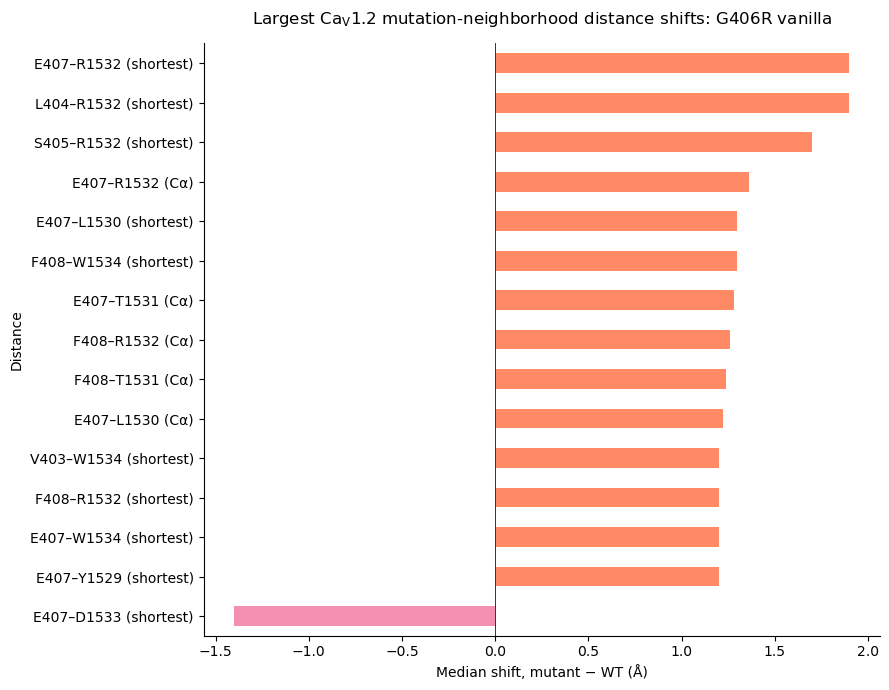

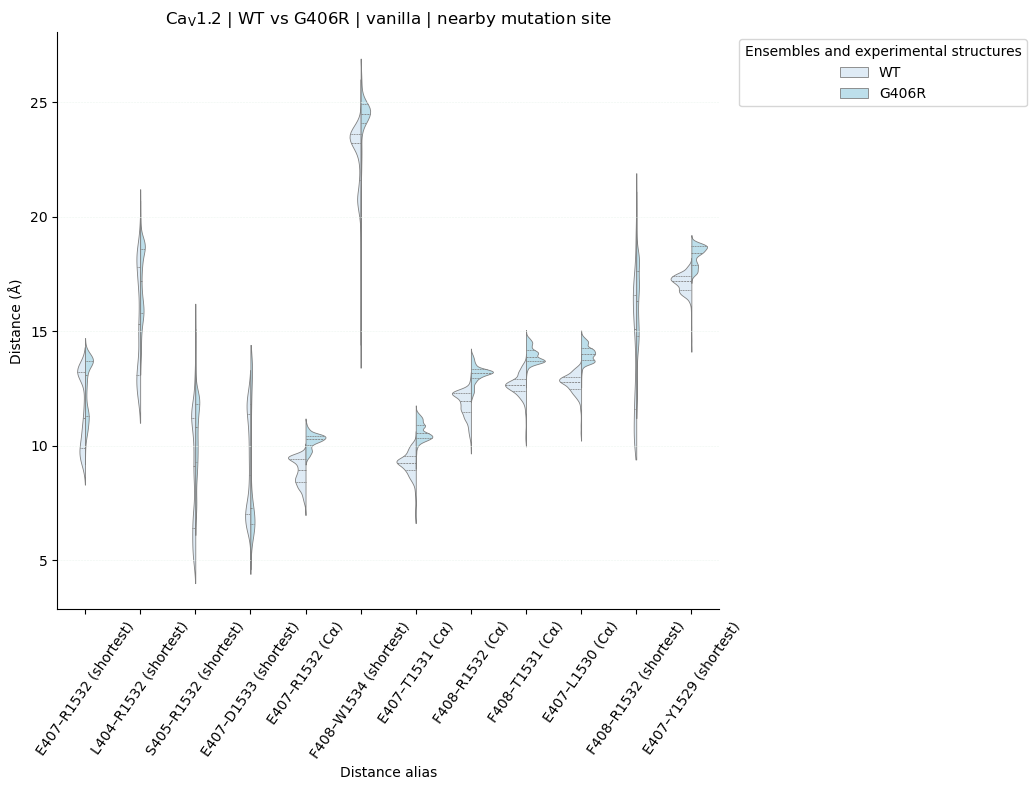

,distance,wt_median_A,mutant_median_A,median_shift_A,abs_shift_A
99,shortest_PHE408-ASP1533,20.50,17.20,-3.30,3.30
82,shortest_GLU407-ASP1533,12.20,9.10,-3.10,3.10
48,shortest_LEU404-ASP1533,19.10,16.60,-2.50,2.50
98,shortest_PHE408-ARG1532,16.70,18.60,1.90,1.90
64,shortest_SER405-ARG1532,10.20,12.00,1.80,1.80
47,shortest_LEU404-ARG1532,17.00,18.50,1.50,1.50
182,CA_GLU407_CA-THR1531_CA,9.28,10.48,1.20,1.20
81,shortest_GLU407-ARG1532,12.50,13.70,1.20,1.20
199,CA_PHE408_CA-THR1531_CA,12.68,13.86,1.18,1.18
181,CA_GLU407_CA-LEU1530_CA,12.86,13.96,1.10,1.10


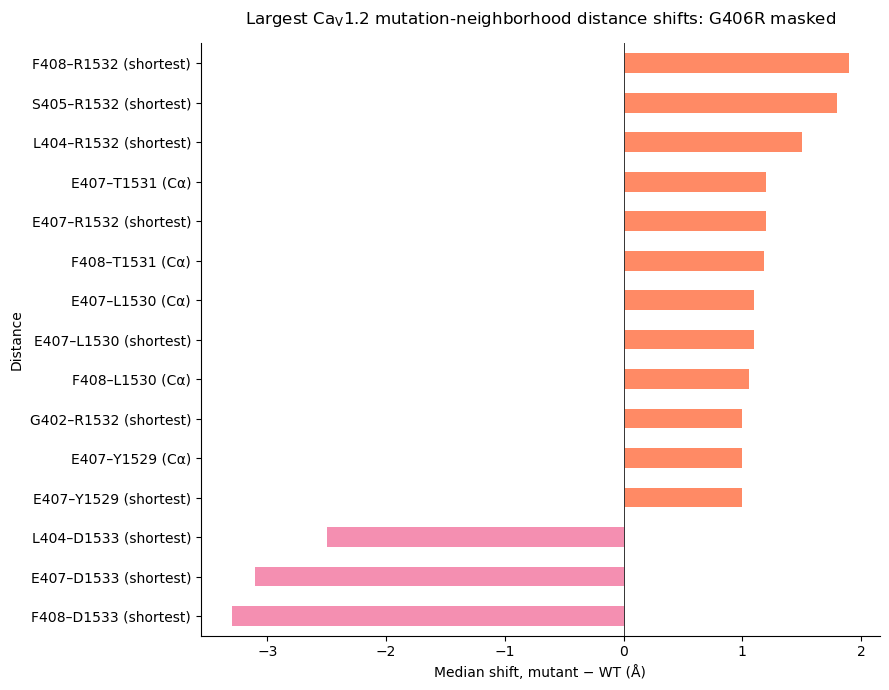

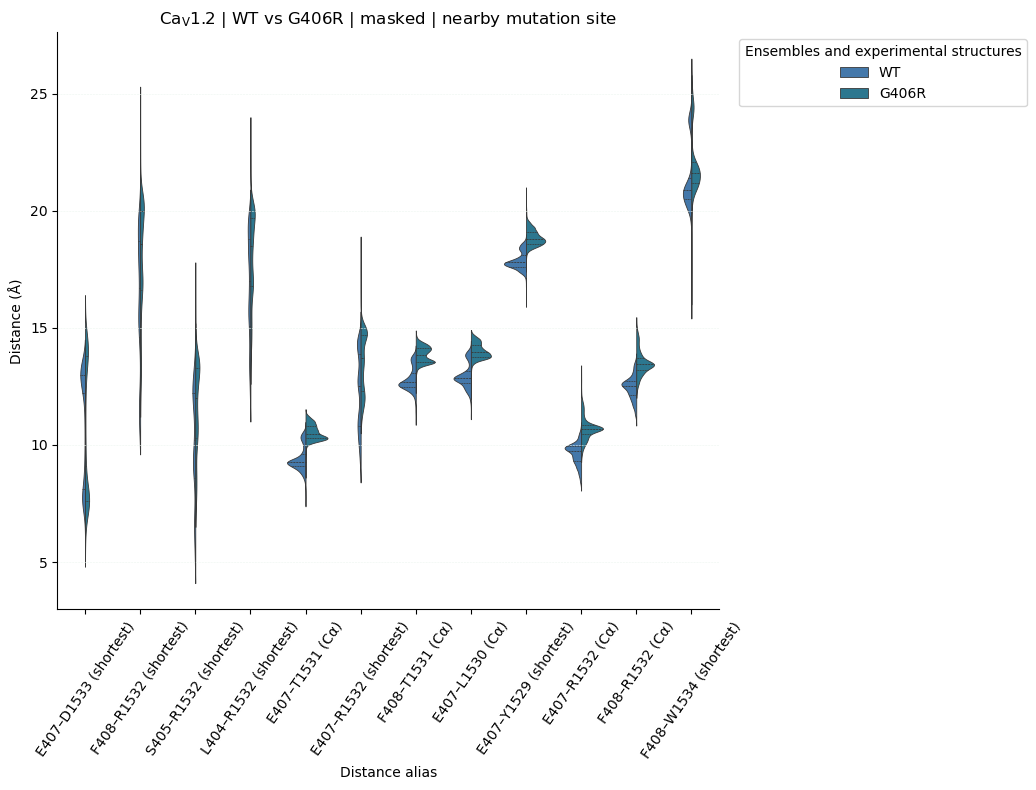

G406R vanilla contacts: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-07-25_Cav1.2_g406r_vanillaAF2_distances_all_ok_rmsd_3A.csv
G406R masked contacts: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-07-25_Cav1.2_g406r_maskedAF2_distances_all_ok_rmsd_3A.csv


,Protocol,Mutant residue,Partner,n,Median (Å),5th percentile (Å),95th percentile (Å),Plausible contact 2–4 Å,Atomic overlap <2 Å,Shortest distance ≤4 Å,Masked − vanilla median (Å),Masked − vanilla plausible-contact fraction,Masked − vanilla overlap fraction,Contact interpretation
31,masked,ARG406,THR1531,4997,1.30,0.8,2.6,0.218,0.781,0.999,-1.00,-0.530,0.529,overlap-sensitive; inspect structures
12,vanilla,ARG406,THR1531,5000,2.30,1.6,3.0,0.748,0.252,1.000,-1.00,-0.530,0.529,overlap-sensitive; inspect structures
9,vanilla,ARG406,ASP1528,5000,4.90,1.8,5.8,0.133,0.073,0.206,0.00,0.122,-0.073,overlap-sensitive; inspect structures
14,vanilla,ARG406,ASP1533,5000,4.40,2.5,7.5,0.288,0.001,0.290,0.80,-0.201,-0.001,recurrent plausible contact
28,masked,ARG406,ASP1528,4997,4.90,3.2,5.8,0.255,0.000,0.255,0.00,0.122,-0.073,overlap-sensitive; inspect structures
33,masked,ARG406,ASP1533,4997,5.20,3.7,8.1,0.088,0.000,0.088,0.80,-0.201,-0.001,recurrent plausible contact
27,masked,ARG406,PHE1527,4997,4.90,4.2,5.7,0.006,0.000,0.006,-0.70,0.006,0.000,rare plausible contact
13,vanilla,ARG406,ARG1532,5000,8.10,4.6,9.2,0.004,0.000,0.004,0.10,-0.004,0.000,rare plausible contact
16,vanilla,ARG406,SER1535,5000,7.60,4.6,9.4,0.000,0.000,0.000,0.10,-0.000,0.000,rare plausible contact
8,vanilla,ARG406,PHE1527,5000,5.60,5.2,7.1,0.000,0.000,0.000,-0.70,0.006,0.000,rare plausible contact


,Structure,State,Chain,Raw site,Site identity,Site PDB residue,Partner,Partner PDB residue,Closest site atom,Closest partner atom,Shortest distance (Å),Cα distance (Å),Distance definition
0,8WE6,WT experimental,A,406,G,406,THR1531,1531,O,CG2,3.139,5.240,minimum non-hydrogen atom pair
1,8WE6,WT experimental,A,406,G,406,ASP1533,1533,O,N,7.767,10.401,minimum non-hydrogen atom pair
2,8WE6,WT experimental,A,406,G,406,ASP1528,1528,CA,N,8.220,8.864,minimum non-hydrogen atom pair
3,8WE6,WT experimental,A,406,G,406,PHE1527,1527,CA,CE1,3.914,6.602,minimum non-hydrogen atom pair
4,8HLP,WT experimental,A,406,G,406,THR1531,1531,CA,OG1,3.548,4.814,minimum non-hydrogen atom pair
5,8HLP,WT experimental,A,406,G,406,ASP1533,1533,O,N,8.122,10.121,minimum non-hydrogen atom pair
6,8HLP,WT experimental,A,406,G,406,ASP1528,1528,CA,O,8.129,8.805,minimum non-hydrogen atom pair
7,8HLP,WT experimental,A,406,G,406,PHE1527,1527,CA,CD1,5.479,6.758,minimum non-hydrogen atom pair
8,8FD7,WT experimental,K,406,G,406,THR1531,1483,N,CA,6.649,7.543,minimum non-hydrogen atom pair
9,8FD7,WT experimental,K,406,G,406,ASP1533,1485,N,N,9.590,9.753,minimum non-hydrogen atom pair


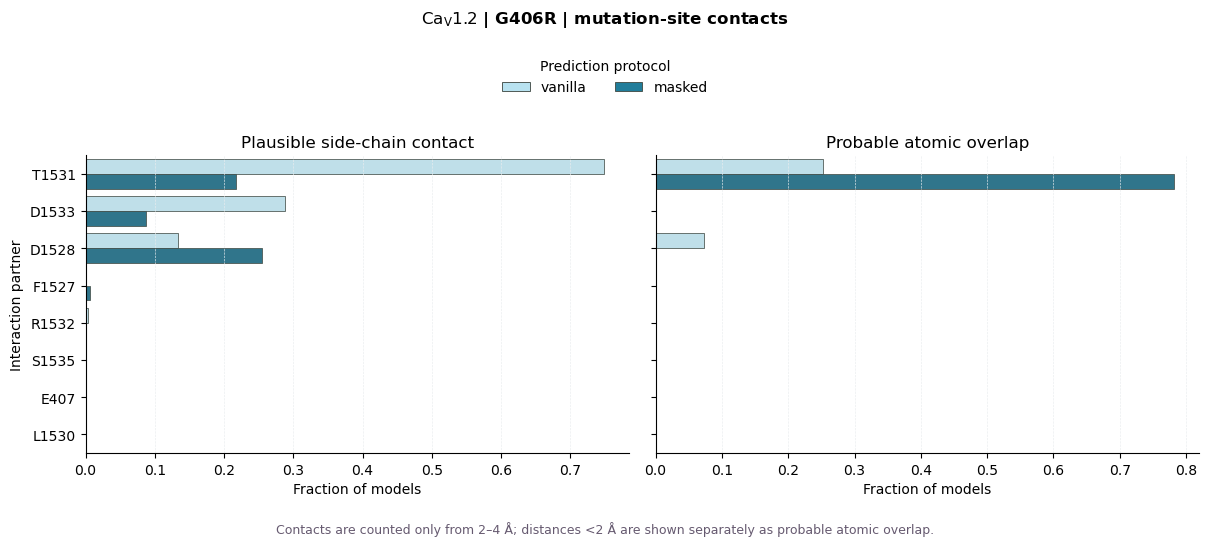

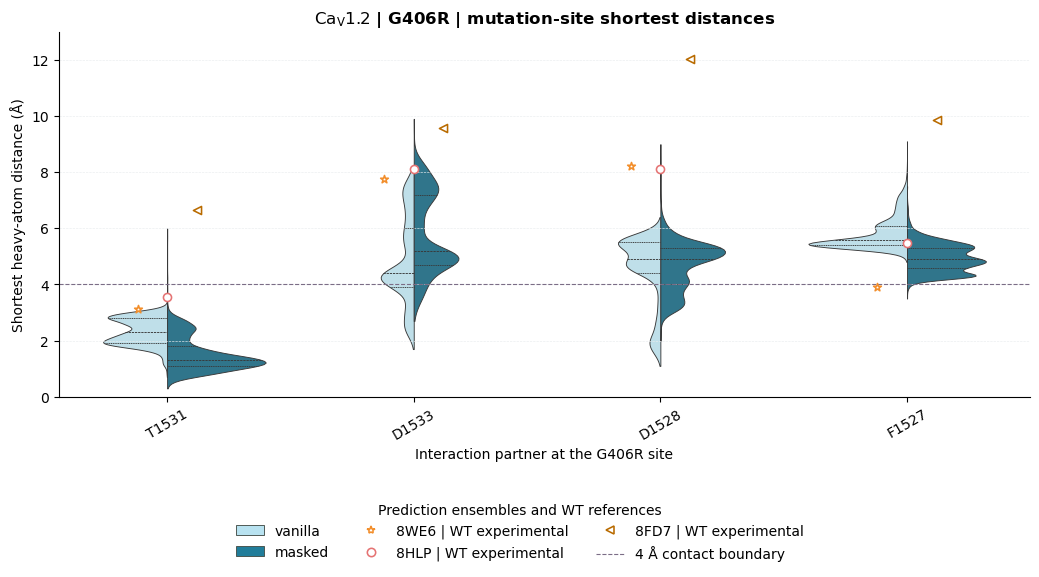

In [4]:
for protocol, wt, mutant, colors in [('vanilla', wt_van, mut_van, (CAV12_PALETTE['WT_VAN'], CAV12_PALETTE['G406R_VAN'])), ('masked', wt_mask, mut_mask, (CAV12_PALETTE['WT_HM'], CAV12_PALETTE['G406R_HM']))]:
    shifts = rank_nearby_shifts(wt, mutant, nearby_distance_columns(wt, 406))
    display(shifts.head(20))
    if shifts.empty:
        print(f'No complete WT–G406R paired distances are available for {protocol}; skipping the ranked-shift overlay.')
        continue
    if shifts.empty:
        print(f'Skipping {protocol}: no mutation-site distance columns contain values in both WT and G406R ensembles.')
        continue
    plot_top_shifts(shifts, f'Largest Cav1.2 mutation-neighborhood distance shifts: G406R {protocol}')
    experimental_aliases = set(next(iter(G406R_EXPERIMENTAL_DISTANCES.values())))
    shifts = shifts[shifts['distance'].map(lambda column: column.replace('CA_CA_', '').replace('shortest_', '') in experimental_aliases)]
    if shifts.empty:
        print(f'Skipping {protocol}: none of the comparable columns has an explicit experimental distance.')
        continue
    aliases = top_aliases(shifts, n=len(experimental_aliases))
    experimentals = {structure: {alias: values for alias, values in distances.items() if alias in aliases} for structure, distances in G406R_EXPERIMENTAL_DISTANCES.items()}
    plot_nearby_overlay(wt, mutant, aliases, 'Cav1.2', 'G406R', protocol, colors, experimentals, experimental_colors)

## Protocol-resolved contacts made by the introduced ARG406 side chain
import shared.dataset_selection as dataset_selection
import shared.mutation_contact_analysis as mutation_contact_analysis
importlib.reload(dataset_selection)
importlib.reload(mutation_contact_analysis)
load_selected_distance_csv = dataset_selection.load_selected_distance_csv
plot_mutation_protocol_contacts = mutation_contact_analysis.plot_mutation_protocol_contacts
plot_mutant_contact_distributions = mutation_contact_analysis.plot_mutant_contact_distributions
cav12_experimental_shortest_distances = mutation_contact_analysis.cav12_experimental_shortest_distances

# Reload the condition-specific frames here so this section is safe to rerun
# after other notebooks or cells have reused the generic mut_van/mut_mask names.
g406r_contact_vanilla = load_selected_distance_csv(
    'G406R vanilla contacts', DATASET_PATHS['G406R vanilla'], DATASET_SELECTION
)
g406r_contact_masked = load_selected_distance_csv(
    'G406R masked contacts', DATASET_PATHS['G406R masked'], DATASET_SELECTION
)
contact_frames = {
    'vanilla': g406r_contact_vanilla,
    'masked': g406r_contact_masked,
}
contact_colors = {
    'vanilla': CAV12_PALETTE['G406R_VAN'],
    'masked': CAV12_PALETTE['G406R_HM'],
}
g406r_contact_table, g406r_contact_sources, g406r_contact_figure = plot_mutation_protocol_contacts(
    contact_frames,
    'ARG406',
    'G406R',
    contact_colors,
    channel='Cav1.2',
)
display(g406r_contact_table.round(3))

table_dir = repo_root / 'cav12' / 'dataDistances' / 'analysis' / 'tables'
figure_dir = repo_root / 'cav12' / 'dataDistances' / 'analysis' / 'figures'
table_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)
g406r_contact_table.to_csv(table_dir / 'g406r_mutation_site_contacts.csv', index=False)
g406r_contact_sources.to_csv(table_dir / 'g406r_mutation_site_contact_sources.csv', index=False)
g406r_contact_figure.savefig(figure_dir / 'g406r_mutation_site_contact_frequencies.png', dpi=400, bbox_inches='tight')

g406r_experimental_shortest = cav12_experimental_shortest_distances(
    repo_root, raw_site=406, partners=['THR1531', 'ASP1533', 'ASP1528', 'PHE1527']
)
display(g406r_experimental_shortest.round(3))
g406r_experimental_shortest.to_csv(
    table_dir / 'g406r_experimental_wt_shortest_distances.csv', index=False
)

g406r_contact_distributions, g406r_distribution_figure = plot_mutant_contact_distributions(
    contact_frames,
    'ARG406',
    'G406R',
    contact_colors,
    partners=['THR1531', 'ASP1533', 'ASP1528', 'PHE1527'],
    channel='Cav1.2',
    experimental_distances=g406r_experimental_shortest,
)
g406r_distribution_figure.savefig(figure_dir / 'g406r_mutation_site_contact_distributions.png', dpi=400, bbox_inches='tight')
